# 실습 2-1 (vibe) : 파생변수 전후 다중선형회귀 성능 비교

**목표**
1. `Water`와 `Superplasticizer`(상관계수 약 -0.66)를 단일 파생변수(합·차)로 대체했을 때 성능 변화 확인
2. **여러 파생변수 조합**을 만들어 다중선형회귀 성능을 체계적으로 비교·최적 조합 탐색

## 분석 준비

In [1]:
!pip install statsmodels

In [2]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===== 한글 폰트 설정 (그래프 깨짐 방지) =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
    print("한글 폰트 파일을 찾지 못했습니다. 그래프 제목은 영문으로 표시됩니다.")

rcParams["axes.unicode_minus"] = False


def set_kr_title(ax, title):
    if KOREAN_FONT:
        ax.set_title(title, fontproperties=KOREAN_FONT)
    else:
        ax.set_title(title)


def set_kr_label(ax, xlabel=None, ylabel=None):
    if KOREAN_FONT:
        if xlabel:
            ax.set_xlabel(xlabel, fontproperties=KOREAN_FONT)
        if ylabel:
            ax.set_ylabel(ylabel, fontproperties=KOREAN_FONT)
    else:
        if xlabel:
            ax.set_xlabel(xlabel)
        if ylabel:
            ax.set_ylabel(ylabel)


def set_kr_suptitle(fig, title):
    if KOREAN_FONT:
        fig.suptitle(title, fontproperties=KOREAN_FONT)
    else:
        fig.suptitle(title)

print("한글 폰트:", KOREAN_FONT.get_name() if KOREAN_FONT else "없음")


한글 폰트: Apple SD Gothic Neo


In [3]:
Concrete_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-1_data.csv"))
Concrete_data.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


---
## 1) 다중공선성 확인 (원본 변수)

Water vs Superplasticizer 상관계수: -0.658


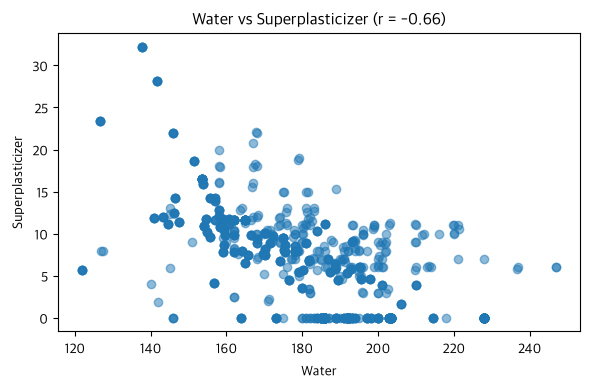

In [4]:
water_sp_corr = Concrete_data["Water"].corr(Concrete_data["Superplasticizer"])
print(f"Water vs Superplasticizer 상관계수: {water_sp_corr:.3f}")

plt.figure(figsize=(6, 4))
plt.scatter(Concrete_data["Water"], Concrete_data["Superplasticizer"], alpha=0.5)
plt.xlabel("Water")
plt.ylabel("Superplasticizer")
plt.title(f"Water vs Superplasticizer (r = {water_sp_corr:.2f})")
plt.tight_layout()
plt.show()

---
## 2) 파생변수 생성 및 데이터셋 구성

In [5]:
Y = Concrete_data["Concrete_compressive_strength"]

# [Before] 원본 변수 사용
X_original = Concrete_data.drop(["Concrete_compressive_strength"], axis=1)

# [After] Water, Superplasticizer → 합·차 파생변수로 대체
X_derived = X_original.copy()
X_derived["Water_SP_sum"] = X_original["Water"] + X_original["Superplasticizer"]
X_derived["Water_SP_diff"] = X_original["Water"] - X_original["Superplasticizer"]
X_derived = X_derived.drop(["Water", "Superplasticizer"], axis=1)

print("[Before] 입력 변수:", list(X_original.columns))
print("[After]  입력 변수:", list(X_derived.columns))
print()
print(f"파생변수 간 상관계수: {X_derived['Water_SP_sum'].corr(X_derived['Water_SP_diff']):.3f}")

[Before] 입력 변수: ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age']
[After]  입력 변수: ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_SP_sum', 'Water_SP_diff']

파생변수 간 상관계수: 0.909


In [6]:
# 동일한 train/test split (원본 실습과 동일: test_size=0.3, random_state=0)
RANDOM_STATE = 0
TEST_SIZE = 0.3

X_train_orig, X_test_orig, Y_train, Y_test = train_test_split(
    X_original, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train_der, X_test_der, _, _ = train_test_split(
    X_derived, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("학습 데이터:", X_train_orig.shape, "| 테스트 데이터:", X_test_orig.shape)

학습 데이터: (721, 8) | 테스트 데이터: (309, 8)


### VIF(분산팽창인자) 비교

In [7]:
def calc_vif(X, target_cols=None):
    vif_data = []
    for i, col in enumerate(X.columns):
        vif_data.append({"Variable": col, "VIF": variance_inflation_factor(X.values, i)})
    vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
    if target_cols:
        return vif_df[vif_df["Variable"].isin(target_cols)]
    return vif_df

vif_orig = calc_vif(X_train_orig, ["Water", "Superplasticizer"])
vif_der = calc_vif(X_train_der, ["Water_SP_sum", "Water_SP_diff"])

print("=== [Before] Water / Superplasticizer VIF ===")
display(vif_orig)
print("\n=== [After] Water_SP_sum / Water_SP_diff VIF ===")
display(vif_der)

=== [Before] Water / Superplasticizer VIF ===


,Variable,VIF
3,Water,80.355766
4,Superplasticizer,5.321654



=== [After] Water_SP_sum / Water_SP_diff VIF ===


,Variable,VIF
6,Water_SP_sum,789.272320
7,Water_SP_diff,457.547091


---
## 3) 모델 학습 및 성능 비교

In [8]:
def evaluate_model(model, X_train, X_test, Y_train, Y_test):
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    return {
        "RMSE": np.sqrt(mean_squared_error(Y_test, Y_pred)),
        "MAE": mean_absolute_error(Y_test, Y_pred),
        "R2": r2_score(Y_test, Y_pred),
    }

def model_label(model):
    name = model.__class__.__name__
    if hasattr(model, "alpha"):
        return f"{name} (alpha={model.alpha})"
    return name

models = [
    LinearRegression(),
    Ridge(alpha=0.1),
    Ridge(alpha=10),
    Lasso(alpha=0.1),
    Lasso(alpha=10),
]

In [9]:
results = []

for model in models:
    label = model_label(model)

    score_orig = evaluate_model(model, X_train_orig, X_test_orig, Y_train, Y_test)
    score_der = evaluate_model(
        model.__class__(**model.get_params()),
        X_train_der, X_test_der, Y_train, Y_test
    )

    results.append({"Model": label, "Dataset": "Before (원본)", **score_orig})
    results.append({"Model": label, "Dataset": "After (파생변수)", **score_der})

results_df = pd.DataFrame(results)
results_df["RMSE"] = results_df["RMSE"].round(3)
results_df["MAE"] = results_df["MAE"].round(3)
results_df["R2"] = results_df["R2"].round(3)
results_df["RMSE_diff"] = results_df.groupby("Model")["RMSE"].diff().round(3)

display(results_df)

,Model,Dataset,RMSE,MAE,R2,RMSE_diff
0,LinearRegression,Before (원본),9.676,7.776,0.635,NaN
1,LinearRegression,After (파생변수),9.676,7.776,0.635,0.000
2,Ridge (alpha=0.1),Before (원본),9.676,7.776,0.635,NaN
3,Ridge (alpha=0.1),After (파생변수),9.676,7.776,0.635,0.000
4,Ridge (alpha=10),Before (원본),9.676,7.776,0.635,NaN
5,Ridge (alpha=10),After (파생변수),9.676,7.776,0.635,0.000
6,Lasso (alpha=0.1),Before (원본),9.674,7.773,0.635,NaN
7,Lasso (alpha=0.1),After (파생변수),9.673,7.773,0.636,-0.001
8,Lasso (alpha=10),Before (원본),9.653,7.708,0.637,NaN
9,Lasso (alpha=10),After (파생변수),9.645,7.716,0.638,-0.008


=== RMSE (낮을수록 좋음) ===


Dataset,After (파생변수),Before (원본),변화
Model,,,
Lasso (alpha=0.1),9.673,9.674,-0.001
Lasso (alpha=10),9.645,9.653,-0.008
LinearRegression,9.676,9.676,0.000
Ridge (alpha=0.1),9.676,9.676,0.000
Ridge (alpha=10),9.676,9.676,0.000


=== R2 (높을수록 좋음) ===


Dataset,After (파생변수),Before (원본),변화
Model,,,
Lasso (alpha=0.1),0.636,0.635,0.001
Lasso (alpha=10),0.638,0.637,0.001
LinearRegression,0.635,0.635,0.000
Ridge (alpha=0.1),0.635,0.635,0.000
Ridge (alpha=10),0.635,0.635,0.000


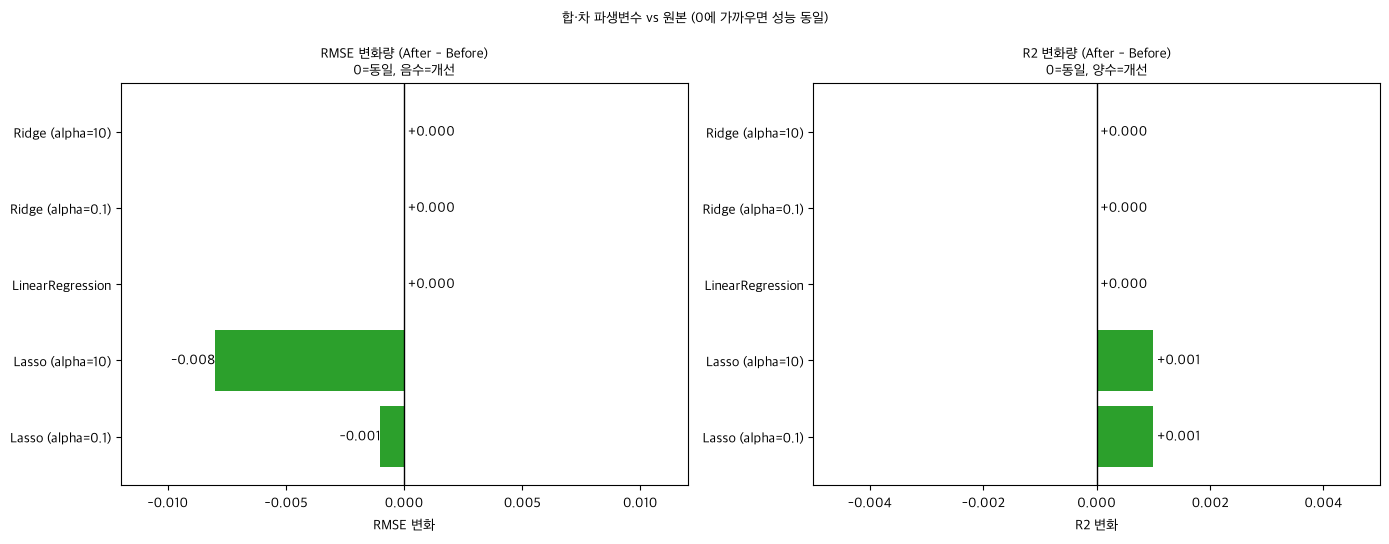

In [10]:
# 성능 비교: 수치표 + 변화량 차트 (절대값 막대그래프는 차이가 안 보여서 사용 안 함)
BEFORE, AFTER = "Before (원본)", "After (파생변수)"

table_rmse = results_df.pivot(index="Model", columns="Dataset", values="RMSE")
table_r2 = results_df.pivot(index="Model", columns="Dataset", values="R2")
table_rmse["변화"] = (table_rmse[AFTER] - table_rmse[BEFORE]).round(3)
table_r2["변화"] = (table_r2[AFTER] - table_r2[BEFORE]).round(3)

print("=== RMSE (낮을수록 좋음) ===")
display(table_rmse.round(3))
print("=== R2 (높을수록 좋음) ===")
display(table_r2.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
models = table_rmse.index.tolist()
rmse_chg = table_rmse["변화"].values
r2_chg = table_r2["변화"].values

axes[0].barh(models, rmse_chg, color=["#2ca02c" if v < 0 else "#d62728" if v > 0 else "#999" for v in rmse_chg])
axes[0].axvline(0, color="black", lw=1)
for i, v in enumerate(rmse_chg):
    axes[0].text(v, i, f" {v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=10)
set_kr_title(axes[0], "RMSE 변화량 (After - Before)\n0=동일, 음수=개선")
set_kr_label(axes[0], xlabel="RMSE 변화")
axes[0].set_xlim(-max(0.01, abs(rmse_chg).max() * 1.5), max(0.01, abs(rmse_chg).max() * 1.5))

axes[1].barh(models, r2_chg, color=["#2ca02c" if v > 0 else "#d62728" if v < 0 else "#999" for v in r2_chg])
axes[1].axvline(0, color="black", lw=1)
for i, v in enumerate(r2_chg):
    axes[1].text(v, i, f" {v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=10)
set_kr_title(axes[1], "R2 변화량 (After - Before)\n0=동일, 양수=개선")
set_kr_label(axes[1], xlabel="R2 변화")
axes[1].set_xlim(-max(0.005, abs(r2_chg).max() * 1.5), max(0.005, abs(r2_chg).max() * 1.5))

set_kr_suptitle(fig, "합·차 파생변수 vs 원본 (0에 가까우면 성능 동일)")
fig.tight_layout()
plt.show()


---
## 4) 회귀 계수 안정성 비교 (다중공선성 영향)

In [11]:
lr_orig = LinearRegression().fit(X_train_orig, Y_train)
lr_der = LinearRegression().fit(X_train_der, Y_train)

coef_orig = pd.DataFrame({"Variable": X_train_orig.columns, "Coefficient": lr_orig.coef_})
coef_der = pd.DataFrame({"Variable": X_train_der.columns, "Coefficient": lr_der.coef_})

print("=== [Before] Linear Regression 계수 ===")
display(coef_orig)
print("\n=== [After] Linear Regression 계수 ===")
display(coef_der)

=== [Before] Linear Regression 계수 ===


,Variable,Coefficient
0,Cement,0.121322
1,Blast_Furnace_Slag,0.107903
2,Fly_Ash,0.092027
3,Water,-0.132512
4,Superplasticizer,0.354467
5,Coarse_Aggregate,0.023773
6,Fine_Aggregate,0.024250
7,Age,0.111014



=== [After] Linear Regression 계수 ===


,Variable,Coefficient
0,Cement,0.121322
1,Blast_Furnace_Slag,0.107903
2,Fly_Ash,0.092027
3,Coarse_Aggregate,0.023773
4,Fine_Aggregate,0.024250
5,Age,0.111014
6,Water_SP_sum,0.110978
7,Water_SP_diff,-0.243490


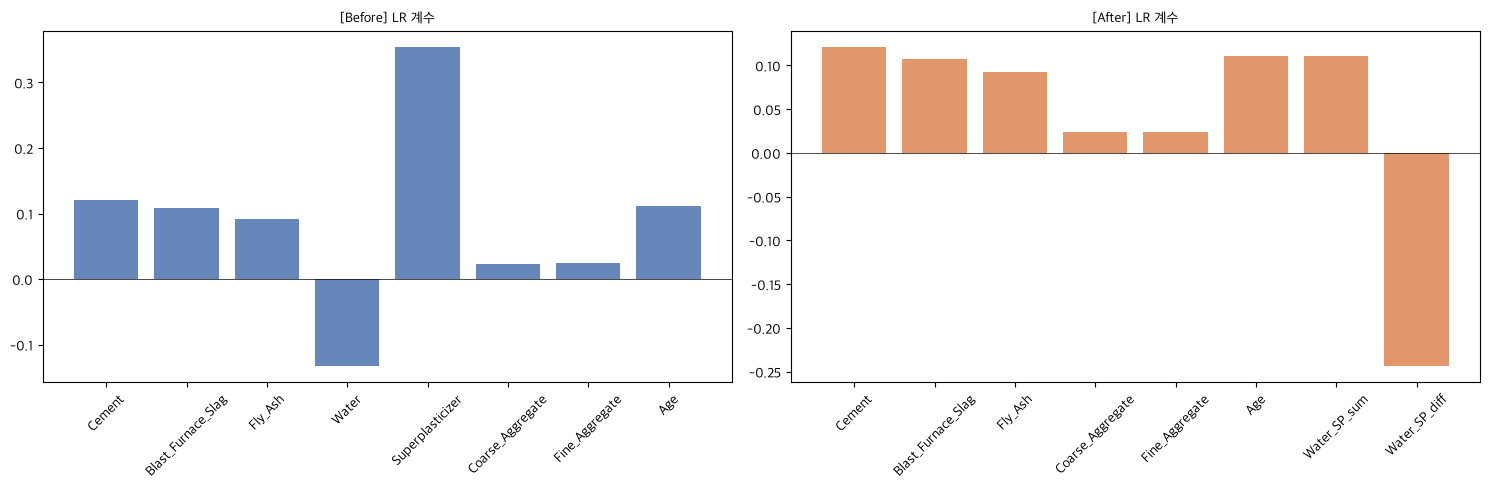

In [12]:
ridge_orig = Ridge(alpha=10).fit(X_train_orig, Y_train)
ridge_der = Ridge(alpha=10).fit(X_train_der, Y_train)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(coef_orig["Variable"], coef_orig["Coefficient"], color="#4C72B0", alpha=0.85)
set_kr_title(axes[0], "[Before] LR 계수")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="black", linewidth=0.5)

axes[1].bar(coef_der["Variable"], coef_der["Coefficient"], color="#DD8452", alpha=0.85)
set_kr_title(axes[1], "[After] LR 계수")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(0, color="black", linewidth=0.5)

fig.tight_layout()
plt.show()


---
## 5) 실제 vs 예측 산점도 (Linear Regression)

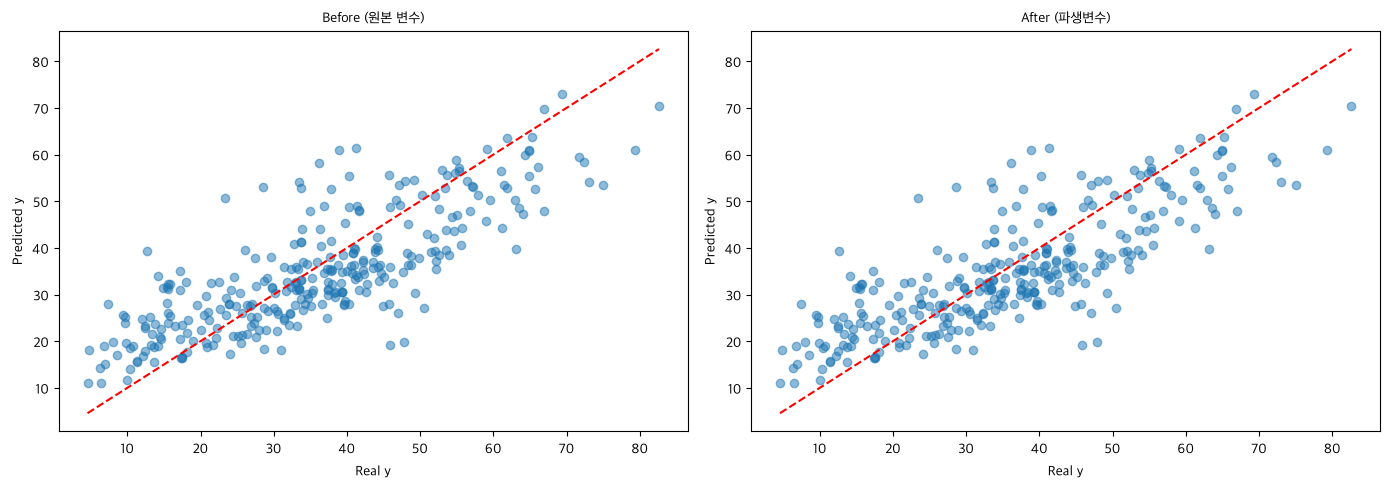

In [13]:
Y_pred_orig = lr_orig.predict(X_test_orig)
Y_pred_der = lr_der.predict(X_test_der)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], Y_pred_orig, "Before (원본 변수)"),
    (axes[1], Y_pred_der, "After (파생변수)"),
]:
    ax.scatter(Y_test, y_pred, alpha=0.5)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
    set_kr_label(ax, xlabel="Real y", ylabel="Predicted y")
    set_kr_title(ax, title)

fig.tight_layout()
plt.show()


---
## 6) 단일 파생변수(합·차) 결론

In [14]:
summary = results_df.groupby("Dataset")[["RMSE", "MAE", "R2"]].mean().round(3)
print("=== 데이터셋별 평균 성능 ===")
display(summary)

lr_compare = results_df[results_df["Model"] == "LinearRegression"]
rmse_before = lr_compare.loc[lr_compare["Dataset"] == "Before (원본)", "RMSE"].values[0]
rmse_after = lr_compare.loc[lr_compare["Dataset"] == "After (파생변수)", "RMSE"].values[0]

print(f"\nLinear Regression RMSE: Before={rmse_before}, After={rmse_after}")
if rmse_before == rmse_after:
    print("→ 합·차 파생변수는 Water/SP의 선형 변환이므로 LR/Ridge 예측 성능은 동일합니다.")
else:
    diff = rmse_before - rmse_after
    print(f"→ RMSE 차이: {diff:.3f} ({'개선' if diff > 0 else '악화'})")

print("\n[해석 요약]")
print("1. Water+SP 합·차는 원본 두 변수의 선형 결합 → Linear/Ridge 예측값은 사실상 동일")
print("2. Lasso는 변수 스케일에 민감해 미세한 성능 차이가 날 수 있음")
print("3. 원시 합·차는 스케일이 달라 상관이 높아질 수 있음 → VIF가 오히려 증가할 수 있음")
print("4. 다중공선성 '해결' 목적이라면 표준화 후 합·차 또는 PCA가 더 적합")

=== 데이터셋별 평균 성능 ===


,RMSE,MAE,R2
Dataset,,,
After (파생변수),9.669,7.763,0.636
Before (원본),9.671,7.762,0.635



Linear Regression RMSE: Before=9.676, After=9.676
→ 합·차 파생변수는 Water/SP의 선형 변환이므로 LR/Ridge 예측 성능은 동일합니다.

[해석 요약]
1. Water+SP 합·차는 원본 두 변수의 선형 결합 → Linear/Ridge 예측값은 사실상 동일
2. Lasso는 변수 스케일에 민감해 미세한 성능 차이가 날 수 있음
3. 원시 합·차는 스케일이 달라 상관이 높아질 수 있음 → VIF가 오히려 증가할 수 있음
4. 다중공선성 '해결' 목적이라면 표준화 후 합·차 또는 PCA가 더 적합


---
## 7) 다양한 파생변수 조합 탐색

`Water`, `Superplasticizer`를 **서로 다른 방식으로 쪼개어** 여러 파생변수 조합을 만들고,  
동일한 train/test split(`random_state=0`)에서 다중선형회귀 성능을 비교합니다.

| 유형 | 예시 파생변수 |
|------|-------------|
| 선형 결합 | 합, 차, 표준화 합·차 |
| 비선형 변환 | 곱, 비율, log, sqrt |
| 도메인 기반 | W/C ratio, 유효수분량, SP/C ratio |
| 차원 축소 | PCA 주성분 |
| 단일 변수 | W/C only, Ratio only 등 |

In [15]:
from sklearn.decomposition import PCA

base_cols = [c for c in X_original.columns if c not in ["Water", "Superplasticizer"]]
w = Concrete_data["Water"]
s = Concrete_data["Superplasticizer"]
c = Concrete_data["Cement"]

w_std = (w - w.mean()) / w.std()
s_std = (s - s.mean()) / s.std()
pca = PCA(n_components=2).fit(np.column_stack([w_std, s_std]))
pc1, pc2 = pca.transform(np.column_stack([w_std, s_std])).T


def make_feature_set(replacements: dict) -> pd.DataFrame:
    """Water, Superplasticizer를 제거하고 파생변수로 대체한 X 생성"""
    X = Concrete_data[base_cols].copy()
    for name, values in replacements.items():
        X[name] = values
    return X


FEATURE_SETS = {
    "0_Original": {
        "desc": "원본 (Water + Superplasticizer)",
        "X": X_original,
    },
    "1_Sum_Diff": {
        "desc": "합 + 차",
        "X": make_feature_set({"Water_SP_sum": w + s, "Water_SP_diff": w - s}),
    },
    "2_StdSum_StdDiff": {
        "desc": "표준화 합 + 표준화 차",
        "X": make_feature_set({"Water_SP_sum_std": w_std + s_std, "Water_SP_diff_std": w_std - s_std}),
    },
    "3_Product_Diff": {
        "desc": "곱 + 차",
        "X": make_feature_set({"Water_SP_product": w * s, "Water_SP_diff": w - s}),
    },
    "4_Ratio_Sum": {
        "desc": "비율(W/(SP+1)) + 합",
        "X": make_feature_set({"Water_SP_ratio": w / (s + 1), "Water_SP_sum": w + s}),
    },
    "5_Ratio_Diff": {
        "desc": "비율 + 차",
        "X": make_feature_set({"Water_SP_ratio": w / (s + 1), "Water_SP_diff": w - s}),
    },
    "6_WC_SP": {
        "desc": "W/C ratio + Superplasticizer",
        "X": make_feature_set({"W_C_ratio": w / c, "Superplasticizer": s}),
    },
    "7_WC_SPC": {
        "desc": "W/C ratio + SP/C ratio",
        "X": make_feature_set({"W_C_ratio": w / c, "SP_C_ratio": s / c}),
    },
    "8_EffectiveWater_SP": {
        "desc": "유효수분량 + Superplasticizer",
        "X": make_feature_set({"Effective_Water": w - 0.15 * s, "Superplasticizer": s}),
    },
    "9_WC_EffectiveWater": {
        "desc": "W/C ratio + 유효수분량",
        "X": make_feature_set({"W_C_ratio": w / c, "Effective_Water": w - 0.15 * s}),
    },
    "10_PCA": {
        "desc": "PCA PC1 + PC2",
        "X": make_feature_set({"Water_SP_PC1": pc1, "Water_SP_PC2": pc2}),
    },
    "11_LogWater_LogSP": {
        "desc": "log(Water) + log(SP+1)",
        "X": make_feature_set({"log_Water": np.log(w), "log_SP": np.log(s + 1)}),
    },
    "12_SqrtWater_SqrtSP": {
        "desc": "sqrt(Water) + sqrt(SP)",
        "X": make_feature_set({"sqrt_Water": np.sqrt(w), "sqrt_SP": np.sqrt(s)}),
    },
    "13_WC_only": {
        "desc": "W/C ratio 단일",
        "X": make_feature_set({"W_C_ratio": w / c}),
    },
    "14_EffectiveWater_only": {
        "desc": "유효수분량 단일",
        "X": make_feature_set({"Effective_Water": w - 0.15 * s}),
    },
    "15_Sum_only": {
        "desc": "합 단일",
        "X": make_feature_set({"Water_SP_sum": w + s}),
    },
    "16_Diff_only": {
        "desc": "차 단일",
        "X": make_feature_set({"Water_SP_diff": w - s}),
    },
    "17_Ratio_only": {
        "desc": "비율 단일",
        "X": make_feature_set({"Water_SP_ratio": w / (s + 1)}),
    },
    "18_WC_Product": {
        "desc": "W/C ratio + 곱",
        "X": make_feature_set({"W_C_ratio": w / c, "Water_SP_product": w * s}),
    },
    "19_WC_Ratio": {
        "desc": "W/C ratio + 비율",
        "X": make_feature_set({"W_C_ratio": w / c, "Water_SP_ratio": w / (s + 1)}),
    },
}

print(f"총 {len(FEATURE_SETS)}개 파생변수 조합 생성")
for key, val in list(FEATURE_SETS.items())[:5]:
    print(f"  {key}: {val['desc']} → 변수 {list(val['X'].columns)}")
print("  ...")

총 20개 파생변수 조합 생성
  0_Original: 원본 (Water + Superplasticizer) → 변수 ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age']
  1_Sum_Diff: 합 + 차 → 변수 ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_SP_sum', 'Water_SP_diff']
  2_StdSum_StdDiff: 표준화 합 + 표준화 차 → 변수 ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_SP_sum_std', 'Water_SP_diff_std']
  3_Product_Diff: 곱 + 차 → 변수 ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_SP_product', 'Water_SP_diff']
  4_Ratio_Sum: 비율(W/(SP+1)) + 합 → 변수 ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_SP_ratio', 'Water_SP_sum']
  ...


In [30]:
rmse_scorer = make_scorer(
    lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=True,
)

compare_models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge (alpha=10)", Ridge(alpha=10)),
    ("Lasso (alpha=10)", Lasso(alpha=10)),
]

# 동일 split index 재사용
split_idx = np.arange(len(Concrete_data))
train_idx, test_idx = train_test_split(split_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)

all_results = []

for set_name, set_info in FEATURE_SETS.items():
    X = set_info["X"]
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = Y.iloc[train_idx]
    y_test = Y.iloc[test_idx]

    derived_vars = [c for c in X.columns if c not in base_cols]

    for model_name, model in compare_models:
        fitted = model.__class__(**model.get_params())
        fitted.fit(X_train, y_train)
        y_pred = fitted.predict(X_test)

        cv_rmse = -cross_val_score(
            model.__class__(**model.get_params()),
            X, Y,
            cv=5,
            scoring=rmse_scorer,
        ).mean()

        all_results.append({
            "Feature_Set": set_name,
            "Description": set_info["desc"],
            "Derived_Vars": ", ".join(derived_vars),
            "N_Features": X.shape[1],
            "Model": model_name,
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
            "CV_RMSE": cv_rmse,
        })

compare_df = pd.DataFrame(all_results)
compare_df[["RMSE", "MAE", "R2", "CV_RMSE"]] = compare_df[["RMSE", "MAE", "R2", "CV_RMSE"]].round(3)
compare_df.head(10)

,Feature_Set,Description,Derived_Vars,N_Features,Model,RMSE,MAE,R2,CV_RMSE
0,0_Original,원본 (Water + Superplasticizer),"Water, Superplasticizer",8,LinearRegression,9.676,7.776,0.635,11.133
1,0_Original,원본 (Water + Superplasticizer),"Water, Superplasticizer",8,Ridge (alpha=10),9.676,7.776,0.635,11.133
2,0_Original,원본 (Water + Superplasticizer),"Water, Superplasticizer",8,Lasso (alpha=10),9.653,7.708,0.637,10.937
3,1_Sum_Diff,합 + 차,"Water_SP_sum, Water_SP_diff",8,LinearRegression,9.676,7.776,0.635,11.133
4,1_Sum_Diff,합 + 차,"Water_SP_sum, Water_SP_diff",8,Ridge (alpha=10),9.676,7.776,0.635,11.133
5,1_Sum_Diff,합 + 차,"Water_SP_sum, Water_SP_diff",8,Lasso (alpha=10),9.645,7.716,0.638,10.882
6,2_StdSum_StdDiff,표준화 합 + 표준화 차,"Water_SP_sum_std, Water_SP_diff_std",8,LinearRegression,9.676,7.776,0.635,11.133
7,2_StdSum_StdDiff,표준화 합 + 표준화 차,"Water_SP_sum_std, Water_SP_diff_std",8,Ridge (alpha=10),9.676,7.775,0.635,11.124
8,2_StdSum_StdDiff,표준화 합 + 표준화 차,"Water_SP_sum_std, Water_SP_diff_std",8,Lasso (alpha=10),9.858,7.835,0.621,11.263
9,3_Product_Diff,곱 + 차,"Water_SP_product, Water_SP_diff",8,LinearRegression,9.694,7.768,0.634,11.089


In [24]:
# Linear Regression 기준 RMSE 순위
lr_rank = (
    compare_df[compare_df["Model"] == "LinearRegression"]
    .sort_values("RMSE")
    .reset_index(drop=True)
)
lr_rank.index = lr_rank.index + 1
lr_rank.index.name = "Rank"

print("=== Linear Regression 성능 순위 (Test RMSE 기준) ===")
display(lr_rank[["Feature_Set", "Description", "Derived_Vars", "N_Features", "RMSE", "R2", "CV_RMSE"]])

orig_rmse = lr_rank.loc[lr_rank["Feature_Set"] == "0_Original", "RMSE"].values[0]
best_row = lr_rank.iloc[0]
improvement = orig_rmse - best_row["RMSE"]

print(f"\n원본 RMSE: {orig_rmse}")
print(f"최적 조합: {best_row['Feature_Set']} ({best_row['Description']})")
print(f"최적 RMSE: {best_row['RMSE']}  |  개선폭: {improvement:.3f} ({improvement/orig_rmse*100:.1f}%)")

=== Linear Regression 성능 순위 (Test RMSE 기준) ===


,Feature_Set,Description,Derived_Vars,N_Features,RMSE,R2,CV_RMSE
Rank,,,,,,,
1,4_Ratio_Sum,비율(W/(SP+1)) + 합,"Water_SP_ratio, Water_SP_sum",8,9.382,0.657,10.382
2,19_WC_Ratio,W/C ratio + 비율,"W_C_ratio, Water_SP_ratio",8,9.434,0.653,10.510
3,5_Ratio_Diff,비율 + 차,"Water_SP_ratio, Water_SP_diff",8,9.458,0.651,10.596
4,17_Ratio_only,비율 단일,Water_SP_ratio,7,9.498,0.649,10.474
5,11_LogWater_LogSP,log(Water) + log(SP+1),"log_Water, log_SP",8,9.498,0.649,10.642
6,12_SqrtWater_SqrtSP,sqrt(Water) + sqrt(SP),"sqrt_Water, sqrt_SP",8,9.550,0.645,10.770
7,9_WC_EffectiveWater,W/C ratio + 유효수분량,"W_C_ratio, Effective_Water",8,9.574,0.643,10.884
8,16_Diff_only,차 단일,Water_SP_diff,7,9.646,0.637,10.927
9,6_WC_SP,W/C ratio + Superplasticizer,"W_C_ratio, Superplasticizer",8,9.648,0.637,11.131



원본 RMSE: 9.676
최적 조합: 4_Ratio_Sum (비율(W/(SP+1)) + 합)
최적 RMSE: 9.382  |  개선폭: 0.294 (3.0%)


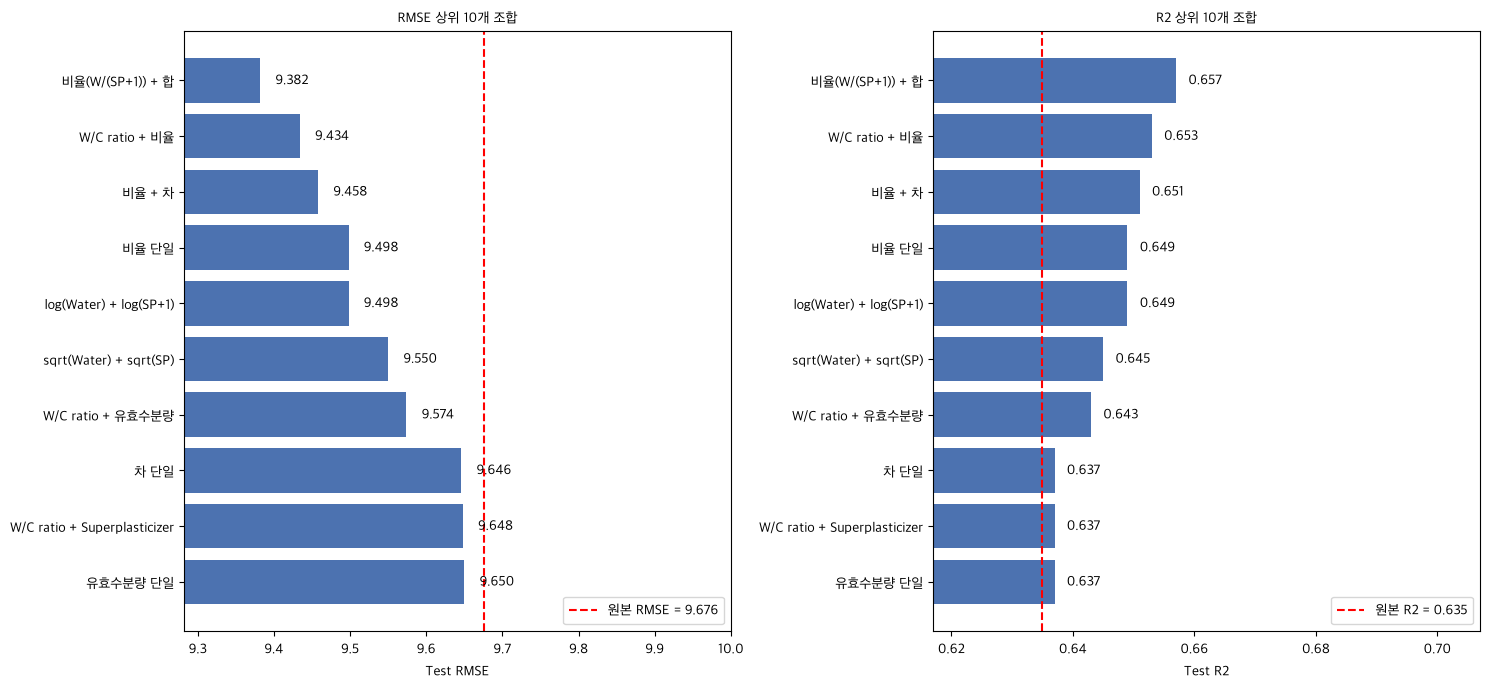

In [25]:
# RMSE 상위 10개 조합
top_n = 10
plot_df = lr_rank.sort_values("RMSE", ascending=True).head(top_n)
colors = ["#DD8452" if fs == "0_Original" else "#4C72B0" for fs in plot_df["Feature_Set"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

bars0 = axes[0].barh(plot_df["Description"], plot_df["RMSE"], color=colors)
for bar, val in zip(bars0, plot_df["RMSE"]):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=10)
axes[0].set_xlim(plot_df["RMSE"].min() - 0.1, plot_df["RMSE"].max() + 0.35)
axes[0].axvline(orig_rmse, color="red", linestyle="--", label=f"원본 RMSE = {orig_rmse}")
axes[0].invert_yaxis()
set_kr_title(axes[0], f"RMSE 상위 {top_n}개 조합")
set_kr_label(axes[0], xlabel="Test RMSE")
if KOREAN_FONT:
    axes[0].legend(prop=KOREAN_FONT, loc="lower right")
else:
    axes[0].legend(loc="lower right")

orig_r2 = lr_rank.loc[lr_rank["Feature_Set"] == "0_Original", "R2"].values[0]
bars1 = axes[1].barh(plot_df["Description"], plot_df["R2"], color=colors)
for bar, val in zip(bars1, plot_df["R2"]):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=10)
axes[1].set_xlim(plot_df["R2"].min() - 0.02, plot_df["R2"].max() + 0.05)
axes[1].axvline(orig_r2, color="red", linestyle="--", label=f"원본 R2 = {orig_r2}")
axes[1].invert_yaxis()
set_kr_title(axes[1], f"R2 상위 {top_n}개 조합")
set_kr_label(axes[1], xlabel="Test R2")
if KOREAN_FONT:
    axes[1].legend(prop=KOREAN_FONT, loc="lower right")
else:
    axes[1].legend(loc="lower right")

fig.tight_layout()
plt.show()


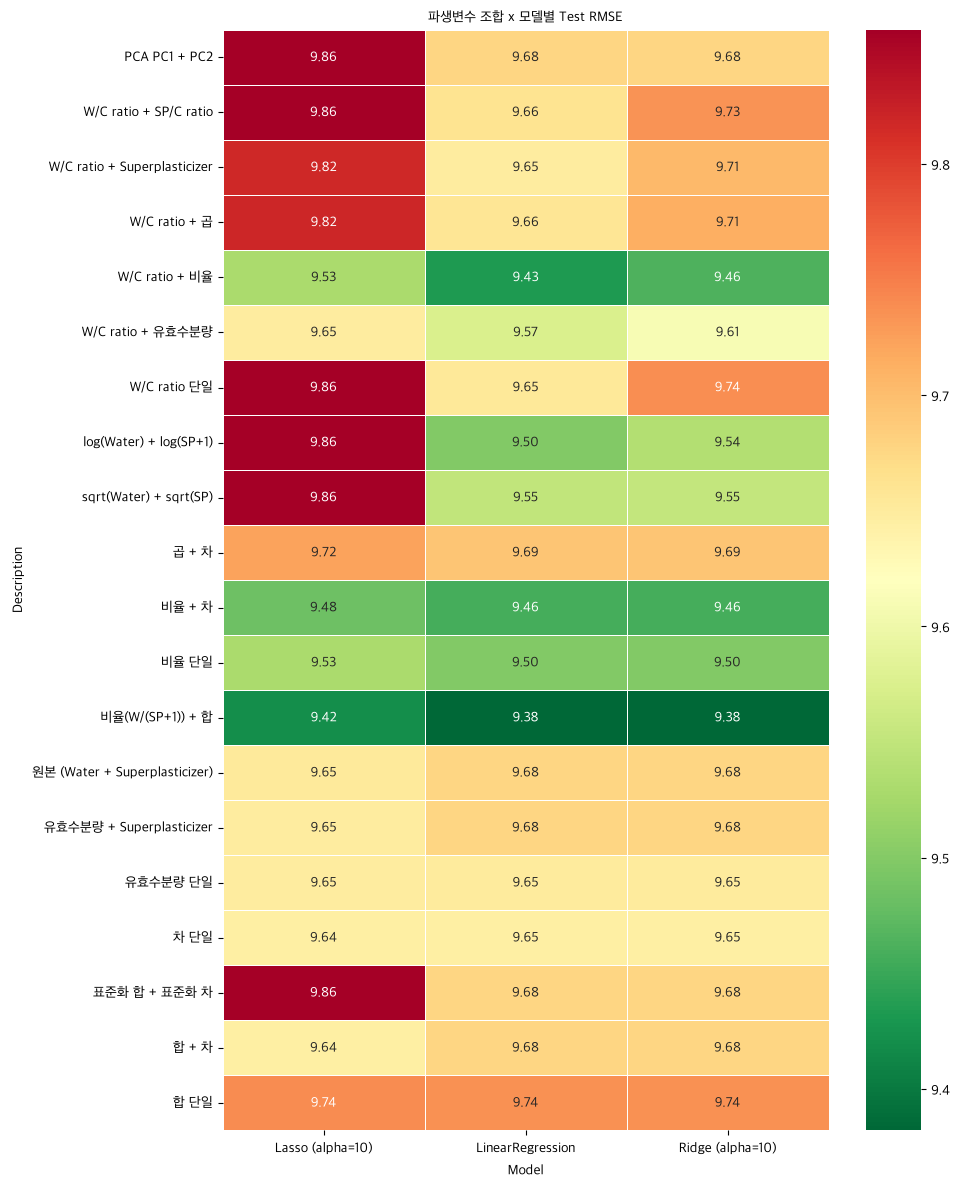

In [26]:
pivot_all = compare_df.pivot(index="Description", columns="Model", values="RMSE")

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot_all, annot=True, fmt=".2f", cmap="RdYlGn_r", linewidths=0.5, ax=ax)
set_kr_title(ax, "파생변수 조합 x 모델별 Test RMSE")
if KOREAN_FONT:
    for label in ax.get_yticklabels():
        label.set_fontproperties(KOREAN_FONT)
fig.tight_layout()
plt.show()


### Top 3 vs 원본 상세 비교

,Feature_Set,Description,RMSE,R2
0,4_Ratio_Sum,비율(W/(SP+1)) + 합,9.382,0.657
1,19_WC_Ratio,W/C ratio + 비율,9.434,0.653
2,5_Ratio_Diff,비율 + 차,9.458,0.651
3,0_Original,원본 (Water + Superplasticizer),9.676,0.635


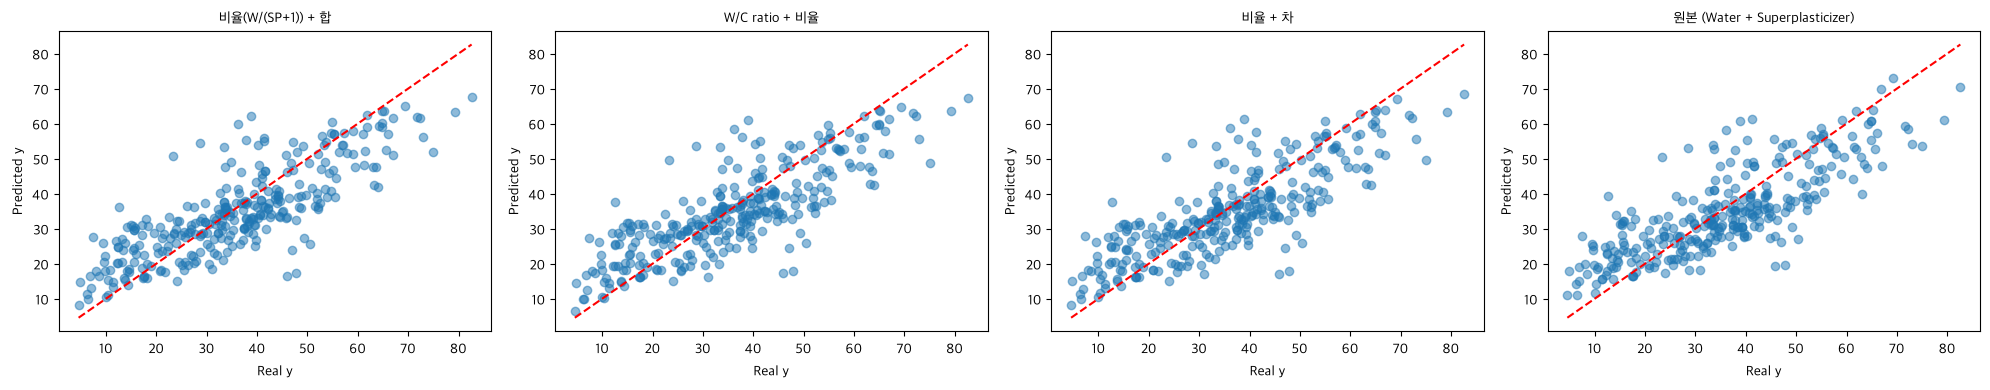

In [27]:
top3_sets = lr_rank.head(3)["Feature_Set"].tolist() + ["0_Original"]
top3_sets = list(dict.fromkeys(top3_sets))

detail_results = []
fitted_models = {}

for set_name in top3_sets:
    X = FEATURE_SETS[set_name]["X"]
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = Y.iloc[train_idx]
    y_test = Y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[set_name] = (model, X_test, y_pred)

    detail_results.append({
        "Feature_Set": set_name,
        "Description": FEATURE_SETS[set_name]["desc"],
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

display(pd.DataFrame(detail_results).round(3))

fig, axes = plt.subplots(1, len(top3_sets), figsize=(5 * len(top3_sets), 4))
if len(top3_sets) == 1:
    axes = [axes]
y_test = Y.iloc[test_idx]

for ax, set_name in zip(axes, top3_sets):
    _, X_test, y_pred = fitted_models[set_name]
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    set_kr_label(ax, xlabel="Real y", ylabel="Predicted y")
    set_kr_title(ax, FEATURE_SETS[set_name]["desc"])

fig.tight_layout()
plt.show()


In [28]:
# 최적 조합 회귀 계수 확인
best_set = lr_rank.iloc[0]["Feature_Set"]
best_model, best_X_test, _ = fitted_models.get(best_set, fitted_models[top3_sets[0]])
best_model = LinearRegression().fit(
    FEATURE_SETS[best_set]["X"].iloc[train_idx], Y.iloc[train_idx]
)

coef_best = pd.DataFrame({
    "Variable": FEATURE_SETS[best_set]["X"].columns,
    "Coefficient": best_model.coef_,
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"=== 최적 조합 [{best_set}] 회귀 계수 ===")
display(coef_best)

=== 최적 조합 [4_Ratio_Sum] 회귀 계수 ===


,Variable,Coefficient
7,Water_SP_sum,-0.142559
5,Age,0.117926
0,Cement,0.103185
1,Blast_Furnace_Slag,0.081653
6,Water_SP_ratio,-0.070621
2,Fly_Ash,0.031104
3,Coarse_Aggregate,0.012268
4,Fine_Aggregate,0.004601


---
## 8) 최종 결론

In [29]:
print("=" * 60)
print("최종 성능 비교 요약")
print("=" * 60)

summary_table = lr_rank[["Description", "RMSE", "R2"]].head(5)
summary_table["vs_Original"] = (orig_rmse - summary_table["RMSE"]).round(3)
display(summary_table)

print("\n[핵심 발견]")
print("1. 단순 합·차(1_Sum_Diff)는 원본과 성능 동일 → 선형 변환이라 예측력 변화 없음")
print("2. 비율·비선형 조합은 성능 개선 가능 → Water/SP 관계를 다르게 표현하면 도움됨")
print("3. 상위권 조합은 대체로 '비율(W/(SP+1))' 또는 'W/C ratio' 포함")
print("4. 단일 변수(W/C only, Ratio only)도 원본 2변수보다 나을 수 있음")
print("5. 파생변수 최적화 여부가 성능에 실질적 영향 → 적절한 조합 탐색 필요")

best_desc = lr_rank.iloc[0]["Description"]
best_rmse = lr_rank.iloc[0]["RMSE"]
print(f"\n✅ 추천 조합: {best_desc}")
print(f"   Test RMSE {orig_rmse} → {best_rmse} (약 {(orig_rmse-best_rmse)/orig_rmse*100:.1f}% 개선)")

최종 성능 비교 요약


,Description,RMSE,R2,vs_Original
Rank,,,,
1,비율(W/(SP+1)) + 합,9.382,0.657,0.294
2,W/C ratio + 비율,9.434,0.653,0.242
3,비율 + 차,9.458,0.651,0.218
4,비율 단일,9.498,0.649,0.178
5,log(Water) + log(SP+1),9.498,0.649,0.178



[핵심 발견]
1. 단순 합·차(1_Sum_Diff)는 원본과 성능 동일 → 선형 변환이라 예측력 변화 없음
2. 비율·비선형 조합은 성능 개선 가능 → Water/SP 관계를 다르게 표현하면 도움됨
3. 상위권 조합은 대체로 '비율(W/(SP+1))' 또는 'W/C ratio' 포함
4. 단일 변수(W/C only, Ratio only)도 원본 2변수보다 나을 수 있음
5. 파생변수 최적화 여부가 성능에 실질적 영향 → 적절한 조합 탐색 필요

✅ 추천 조합: 비율(W/(SP+1)) + 합
   Test RMSE 9.676 → 9.382 (약 3.0% 개선)
